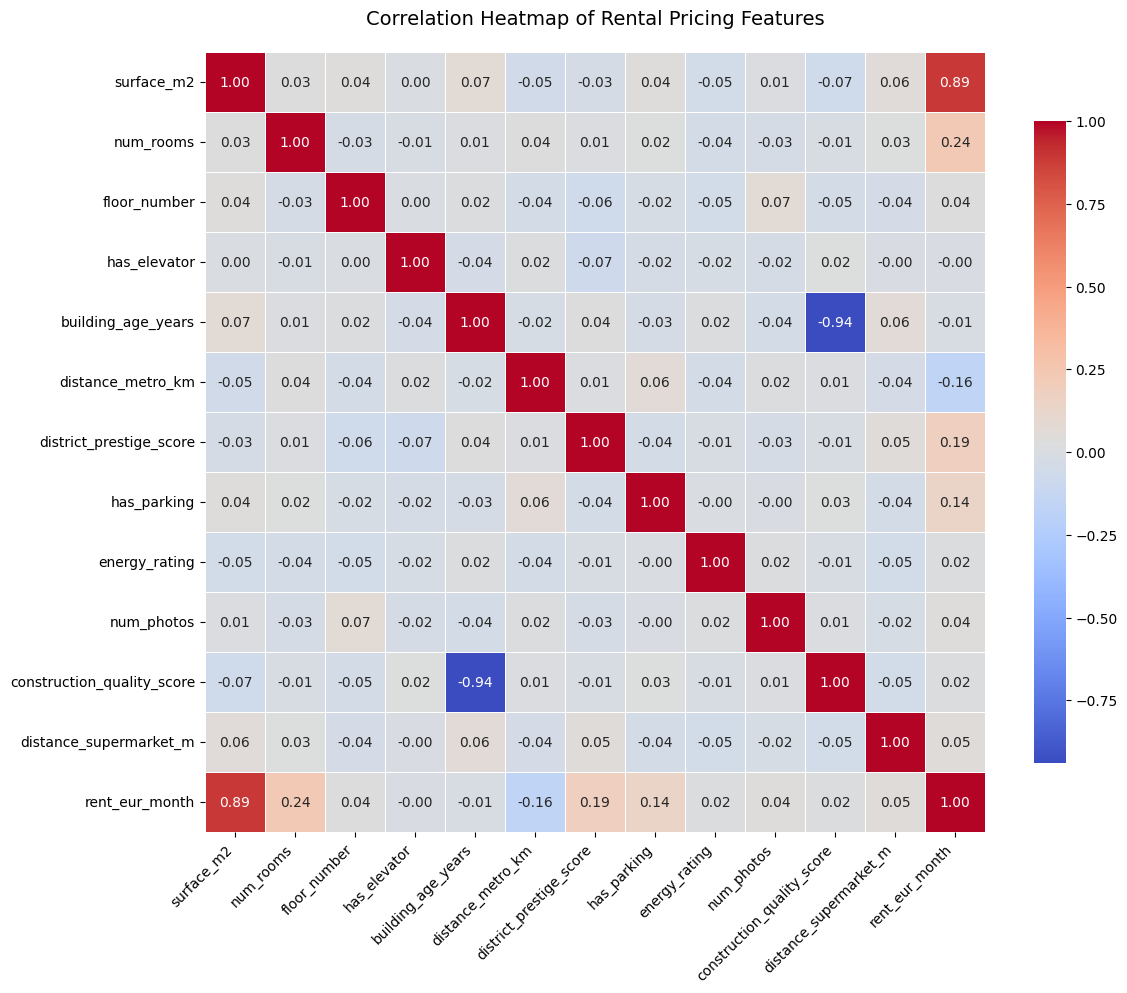

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
df_train = pd.read_csv('track_a_rental_pricing_train.csv')
df_test = pd.read_csv('track_a_rental_pricing_test.csv')

# Split into features and target
X_train = df_train.drop(columns=['rent_eur_month'])
Y_train = df_train['rent_eur_month']
X_test = df_test.drop(columns=['rent_eur_month'])
Y_test = df_test['rent_eur_month']

# Compute the Pearson correlation matrix using the full training set
correlation_matrix = df_train.corr()

# Set up the plot using subplots
fig, ax = plt.subplots(figsize=(12, 10))

# Create the heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    square=True, 
    ax=ax, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# Format the labels and title for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation Heatmap of Rental Pricing Features', fontsize=14, pad=20)

# Adjust layout to prevent clipping of labels
plt.tight_layout()

# Save the plot
# plt.savefig('correlation_heatmap.png', dpi=300)
plt.show()
plt.close()

SKEWNESS OF THE RENT DATA 

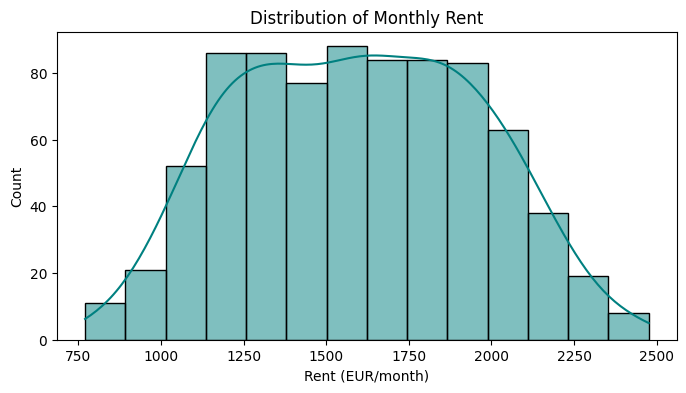

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df_train['rent_eur_month'], kde=True, color='teal')
plt.title('Distribution of Monthly Rent', fontsize=12)
plt.xlabel('Rent (EUR/month)')
plt.ylabel('Count')
plt.show()

In [7]:
print(f"Minimum Rent:  {Y_train.min():.2f} EUR")
print(f"Maximum Rent:  {Y_train.max():.2f} EUR")
print(f"Mean Rent:     {Y_train.mean():.2f} EUR")
print(f"Median Rent:   {Y_train.median():.2f} EUR")
print(f"Skewness:      {Y_train.skew():.2f} ")

Minimum Rent:  770.23 EUR
Maximum Rent:  2475.74 EUR
Mean Rent:     1595.79 EUR
Median Rent:   1599.41 EUR
Skewness:      0.04 


--> highly symmetric data

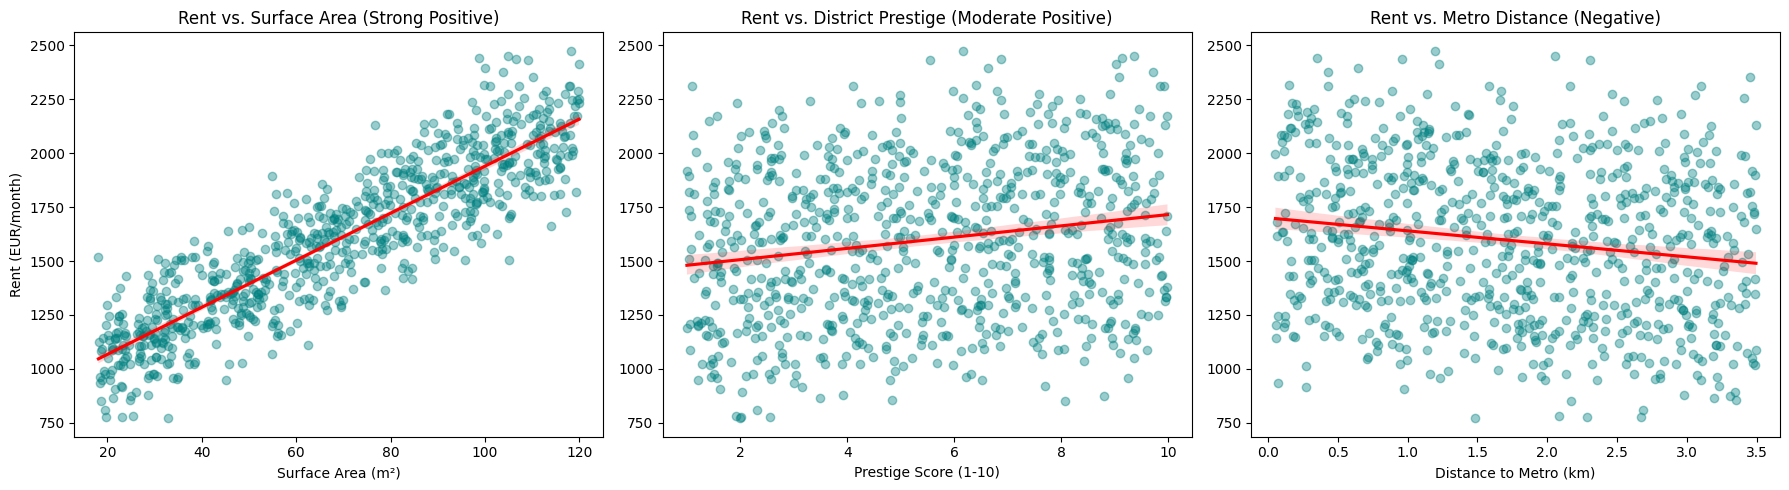

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Rent vs Surface Area
sns.regplot(data=df_train, x='surface_m2', y='rent_eur_month', ax=axes[0],
            scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Rent vs. Surface Area (Strong Positive)')
axes[0].set_xlabel('Surface Area (m²)')
axes[0].set_ylabel('Rent (EUR/month)')

# 2. Rent vs District Prestige
sns.regplot(data=df_train, x='district_prestige_score', y='rent_eur_month', ax=axes[1],
            scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
axes[1].set_title('Rent vs. District Prestige (Moderate Positive)')
axes[1].set_xlabel('Prestige Score (1-10)')
axes[1].set_ylabel('')

# 3. Rent vs Metro Distance
sns.regplot(data=df_train, x='distance_metro_km', y='rent_eur_month', ax=axes[2],
            scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
axes[2].set_title('Rent vs. Metro Distance (Negative)')
axes[2].set_xlabel('Distance to Metro (km)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()